# Comprehensive Evaluation of Machine Learning models on Diamonds Dataset

## Introduction

The main goal of this notebook is to apply all types of algorithm both classification and Regression, so that find out which algorithm fits best and more accurate results, at the end List down all the algorithms results.

## Goals

1. To compare a range of machine learning algorithms for both regression and classification.
2. To select the top performing model based on key performance metrics.
3. To apply the chosen model to dummy data for prediction validation.

## Algorithm Evaluated

In my exploration, I will evaluate the following machine learning algorithms:
### Regression Algorithms:
- Linear Regression
- Support Vector Regression (SVR)
- Decision Tree Regression
- Random Forest Regression
- Gradient Boosting Regression
- AdaBoost Regression
- KNN Regression (K-Nearest Neighbors)
- XGBoost Regression
- CatBoost Regression
- LightGBM Regression
- Gaussian NB Regression
- BernoulliNB Regression
### Classification Algorithms:
- Logistic Regression
- Support Vector Classifier
- Decision Tree Classifier
- Random Forest Classifier
- Gradient Boosting Classifier
- AdaBoost Classifier
- K-Nearest Neighbors Classifier
- XGBoost Classifier
- CatBoost Classifier
- LightGBM Classifier
- GaussianNB
- BernoulliNB

The dataset under scrutiny is the Diamond Dataset. It provides detailed attributes for each diamond, which are critical in determining its quality and value
#### The key features included in the dataset are as follows:
- Carat: Weight of the diamond measured in carats.
- Cut: Quality of the diamond's cut, categorized into grades such as Fair, Good, Very Good, Premium, and Ideal.
- Color: Diamond color grade, ranging from D (colorless) to J (slightly tinted).
- Clarity: Measure of the diamond's clarity, with categories like (Internally Flawless), VVS1/VVS2 (Very Very Slightly Included), VS1/VS2 (Very Slightly
Included), SI1/S12 (Slightly Included), and 11 (Included).
Depth: Total depth percentage calculated as z/mean(x, y) = 2*z/(x + y).
- Table: Width of the diamond's table expressed as a percentage of its average diameter.
- Price: Price of the diamond in US dollars.
- X (Length): Length of the diamond in millimeters (mm).
- Y (Width): Width of the diamond in millimeters (mm).
- Z (Depth): Depth of the diamond in millimeters (mm).

These features collectively contribute to our diamond's appearance, quality, and overall market value.

### Data Preprocessing

To evaluate data, Data preprocessing implemention is important to ensure data is clean and ready for predict something. 

- Missing Values: Conducted a comprehensive check for missing values within the dataset.
- Data Distribution: Examined the distribution and skewness of the dataset to understand the underlying data structure.
- Feature Engineering: Applied appropriate transformations to enhance model performance where necessary.

## Source

This dataset is taken from Seaborn library.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.preprocessing import (
    LabelEncoder, QuantileTransformer, FunctionTransformer,
    StandardScaler, OneHotEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVR, SVC
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier,
    AdaBoostRegressor, AdaBoostClassifier
)
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    mean_absolute_percentage_error, accuracy_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, auc, precision_score, recall_score, f1_score
)
from xgboost import XGBRegressor, XGBClassifier
from catboost import CatBoostRegressor, CatBoostClassifier
# from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
import pickle
import warnings
warnings.filterwarnings('ignore')

### Load Diamond Dataset

Take the sample of 10000 rows of diamond dataset. 

In [22]:
df = sns.load_dataset('diamonds').sample(10000, random_state=42)
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
1388,0.24,Ideal,G,VVS1,62.1,56.0,559,3.97,4.00,2.47
50052,0.58,Very Good,F,VVS2,60.0,57.0,2201,5.44,5.42,3.26
41645,0.40,Ideal,E,VVS2,62.1,55.0,1238,4.76,4.74,2.95
42377,0.43,Premium,E,VVS2,60.8,57.0,1304,4.92,4.89,2.98
17244,1.55,Ideal,E,SI2,62.3,55.0,6901,7.44,7.37,4.61


In [23]:
df.shape

(10000, 10)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1388 to 42497
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    10000 non-null  float64 
 1   cut      10000 non-null  category
 2   color    10000 non-null  category
 3   clarity  10000 non-null  category
 4   depth    10000 non-null  float64 
 5   table    10000 non-null  float64 
 6   price    10000 non-null  int64   
 7   x        10000 non-null  float64 
 8   y        10000 non-null  float64 
 9   z        10000 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 655.2 KB


In [25]:
categorical_count = df.select_dtypes (include=['category']).shape[1]
# Count the number of float columns
float_count = df.select_dtypes (include=['float64']).shape[1]
# Count the number of integer columns
int_count = df.select_dtypes (include=['int64']).shape[1]
# Print the counts in a bullet-point format
print (f". Categorical columns: {categorical_count}")
print (f". Float columns: {float_count}")
print (f". Integer columns: {int_count}")

. Categorical columns: 3
. Float columns: 6
. Integer columns: 1


In [26]:
df.describe()

,carat,depth,table,price,x,y,z
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.795464,61.77341,57.447340,3900.356600,5.722033,5.723494,3.534455
std,0.476937,1.45393,2.255054,3992.251932,1.128186,1.120839,0.696424
min,0.200000,43.00000,49.000000,335.000000,0.000000,0.000000,0.000000
25%,0.400000,61.10000,56.000000,929.750000,4.690000,4.700000,2.900000
50%,0.700000,61.90000,57.000000,2385.500000,5.690000,5.700000,3.520000
75%,1.040000,62.50000,59.000000,5235.250000,6.530000,6.530000,4.030000
max,4.010000,79.00000,73.000000,18823.000000,10.140000,10.100000,6.310000


## Dataset Summary 

In [59]:
# summary + print (fixed f-string)
stats = df.describe().T

print(f"""1. The dataset consists of {int(stats.loc['carat','count'])} diamond records.
2. Diamond carat weights range from {stats.loc['carat','min']} to {stats.loc['carat','max']}, with an average of {stats.loc['carat','mean']:.2f}.
3. The mean depth percentage is {stats.loc['depth','mean']:.2f} %, with a standard deviation of {stats.loc['depth','std']:.2f} %.
4. The average table size is {stats.loc['table','mean']:.2f} %, varying typically by {stats.loc['table','std']:.2f} %.
5. Prices vary widely, from ${stats.loc['price','min']:.2f} to ${stats.loc['price','max']:.2f}, indicating significant diversity in diamond quality.
6. The mean dimensions (length x width x depth) in millimeters are approximately ({stats.loc['x','mean']:.2f} x {stats.loc['y','mean']:.2f} x {stats.loc['z','mean']:.2f}).
7. The standard deviation in the lengths and widths suggests variation in diamond shapes and cuts (x std: {stats.loc['x','std']:.2f}, y std: {stats.loc['y','std']:.2f}).
8. The 50th percentile (median) values are generally close to the mean for carat, depth and table (carat median: {stats.loc['carat','50%']:.2f}, depth median: {stats.loc['depth','50%']:.2f}, table median: {stats.loc['table','50%']:.2f}).
""")

1. The dataset consists of 10000 diamond records.
2. Diamond carat weights range from 0.2 to 4.01, with an average of 0.80.
3. The mean depth percentage is 61.77 %, with a standard deviation of 1.45 %.
4. The average table size is 57.45 %, varying typically by 2.26 %.
5. Prices vary widely, from $335.00 to $18823.00, indicating significant diversity in diamond quality.
6. The mean dimensions (length x width x depth) in millimeters are approximately (5.72 x 5.72 x 3.53).
7. The standard deviation in the lengths and widths suggests variation in diamond shapes and cuts (x std: 1.13, y std: 1.12).
8. The 50th percentile (median) values are generally close to the mean for carat, depth and table (carat median: 0.70, depth median: 61.90, table median: 57.00).



### Ordinal Categorical Variables and Encoding Methods

Given that all the categorical variables in the diamond dataset are ordinal, it would be more appropriate to use Label Encoding rather than One-Hot
Encoding. This is because Label Encoding tends to perform better with ordinal data types.

In [28]:
def encode_columns(df, cols):
    # Instantiate the LabelEncoder
    le = LabelEncoder()
    
    for col in cols:
        # Apply LabelEncoder to each column and update the DataFrame in place
        df[col] = le.fit_transform(df[col])
    
    # Return the modified DataFrame with encoded columns
    return df

### Plotting Correlation Matrix

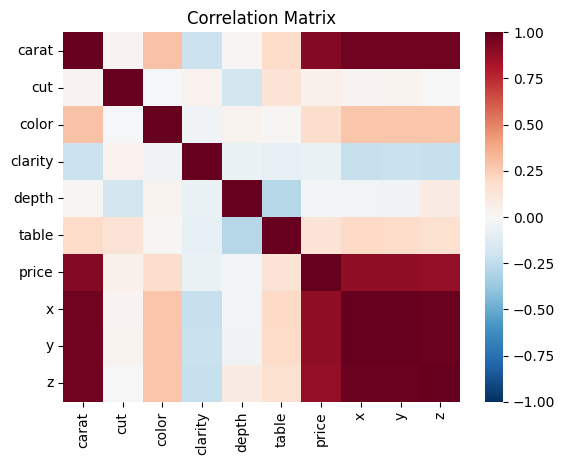

In [61]:
# copy the dataset to a new dataframe for plotting correlation matrix
df_corr = df.copy()
# create a list of categorical features by checking the data type
cat_cols = df_corr.select_dtypes (include=['object', 'category']).columns.tolist()
# Use Label encoder to ordinal features
# le = LabelEncoder(), use label encoder to encode the categorical features in the copied dataframe
df_corr = encode_columns (df_corr, cat_cols)
# plot crr matrix to see the correlation between the variables
plt.title("Correlation Matrix")
corr = df_corr.corr()
# plt.figure(figsize=(15,8))
sns.heatmap(corr, annot=False, cmap='RdBu_r', vmin=-1, vmax=1)
plt.show()

### Correlation Observations in the Diamond Dataset

Correlation matrix shows a strong positive relationship between price and carat. The dimensions (x, y, z) also correlate positively with price, indicating larger diamonds tend to be more expensive.


#### Figuring out the missing values in the dataset

<Axes: >

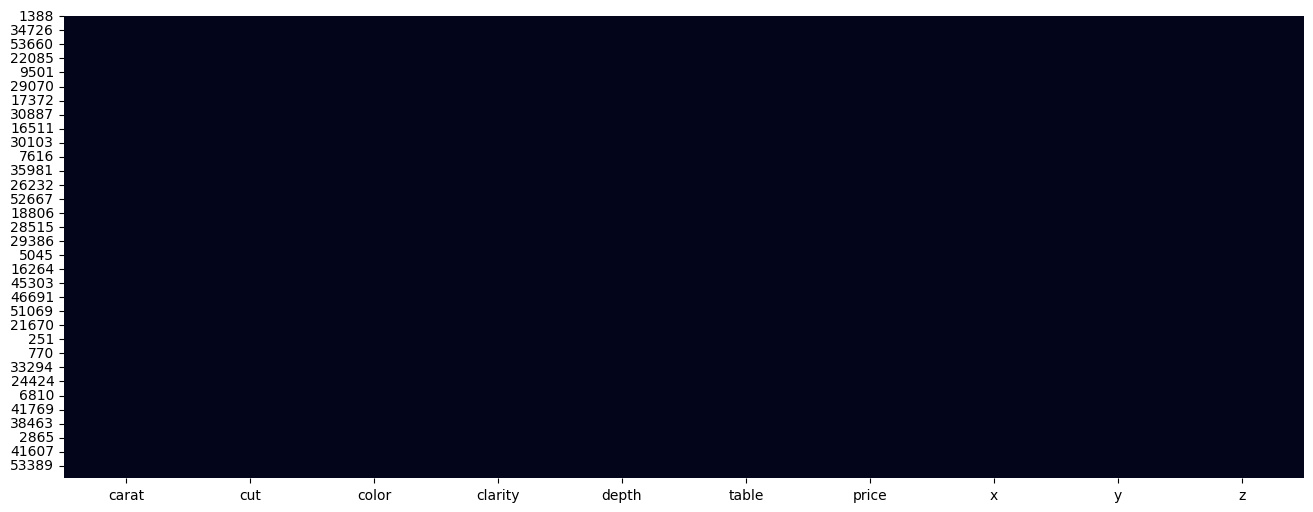

In [30]:
# Plotting Heatmap
# Plotting heatmap to check missing values after imputation
plt.figure(figsize=(16, 6))
sns.heatmap(df.isnull(), cbar=False)
# master 0A6 A0 Select Postgres Server -- NORMAL --

This dataset have no missing values, and ensure dataset ready for machine learning model.

### Data distribution Analysis

In [31]:
# Get the numerical columns
numerical_cols = df.select_dtypes (include=['int64', 'float64']).columns.tolist()
# Calculate the skewness for each numerical column
skewness =df[numerical_cols].skew()
# Create a DataFrame with skewness values as a single row
skewness_df = pd.DataFrame([skewness], index=['Skewness'])
skewness_df

,carat,depth,table,price,x,y,z
Skewness,1.143019,-0.073058,0.770793,1.652864,0.3976,0.392881,0.389912


SKEWNESS ANALYSIS OF NUMERICAL FEATURES

Skewness Values:
       Skewness
carat  1.143019
depth -0.073058
table  0.770793
price  1.652864
x      0.397600
y      0.392881
z      0.389912


SKEWNESS ANALYSIS OF NUMERICAL FEATURES

Skewness Values:
       Skewness
carat  1.143019
depth -0.073058
table  0.770793
price  1.652864
x      0.397600
y      0.392881
z      0.389912


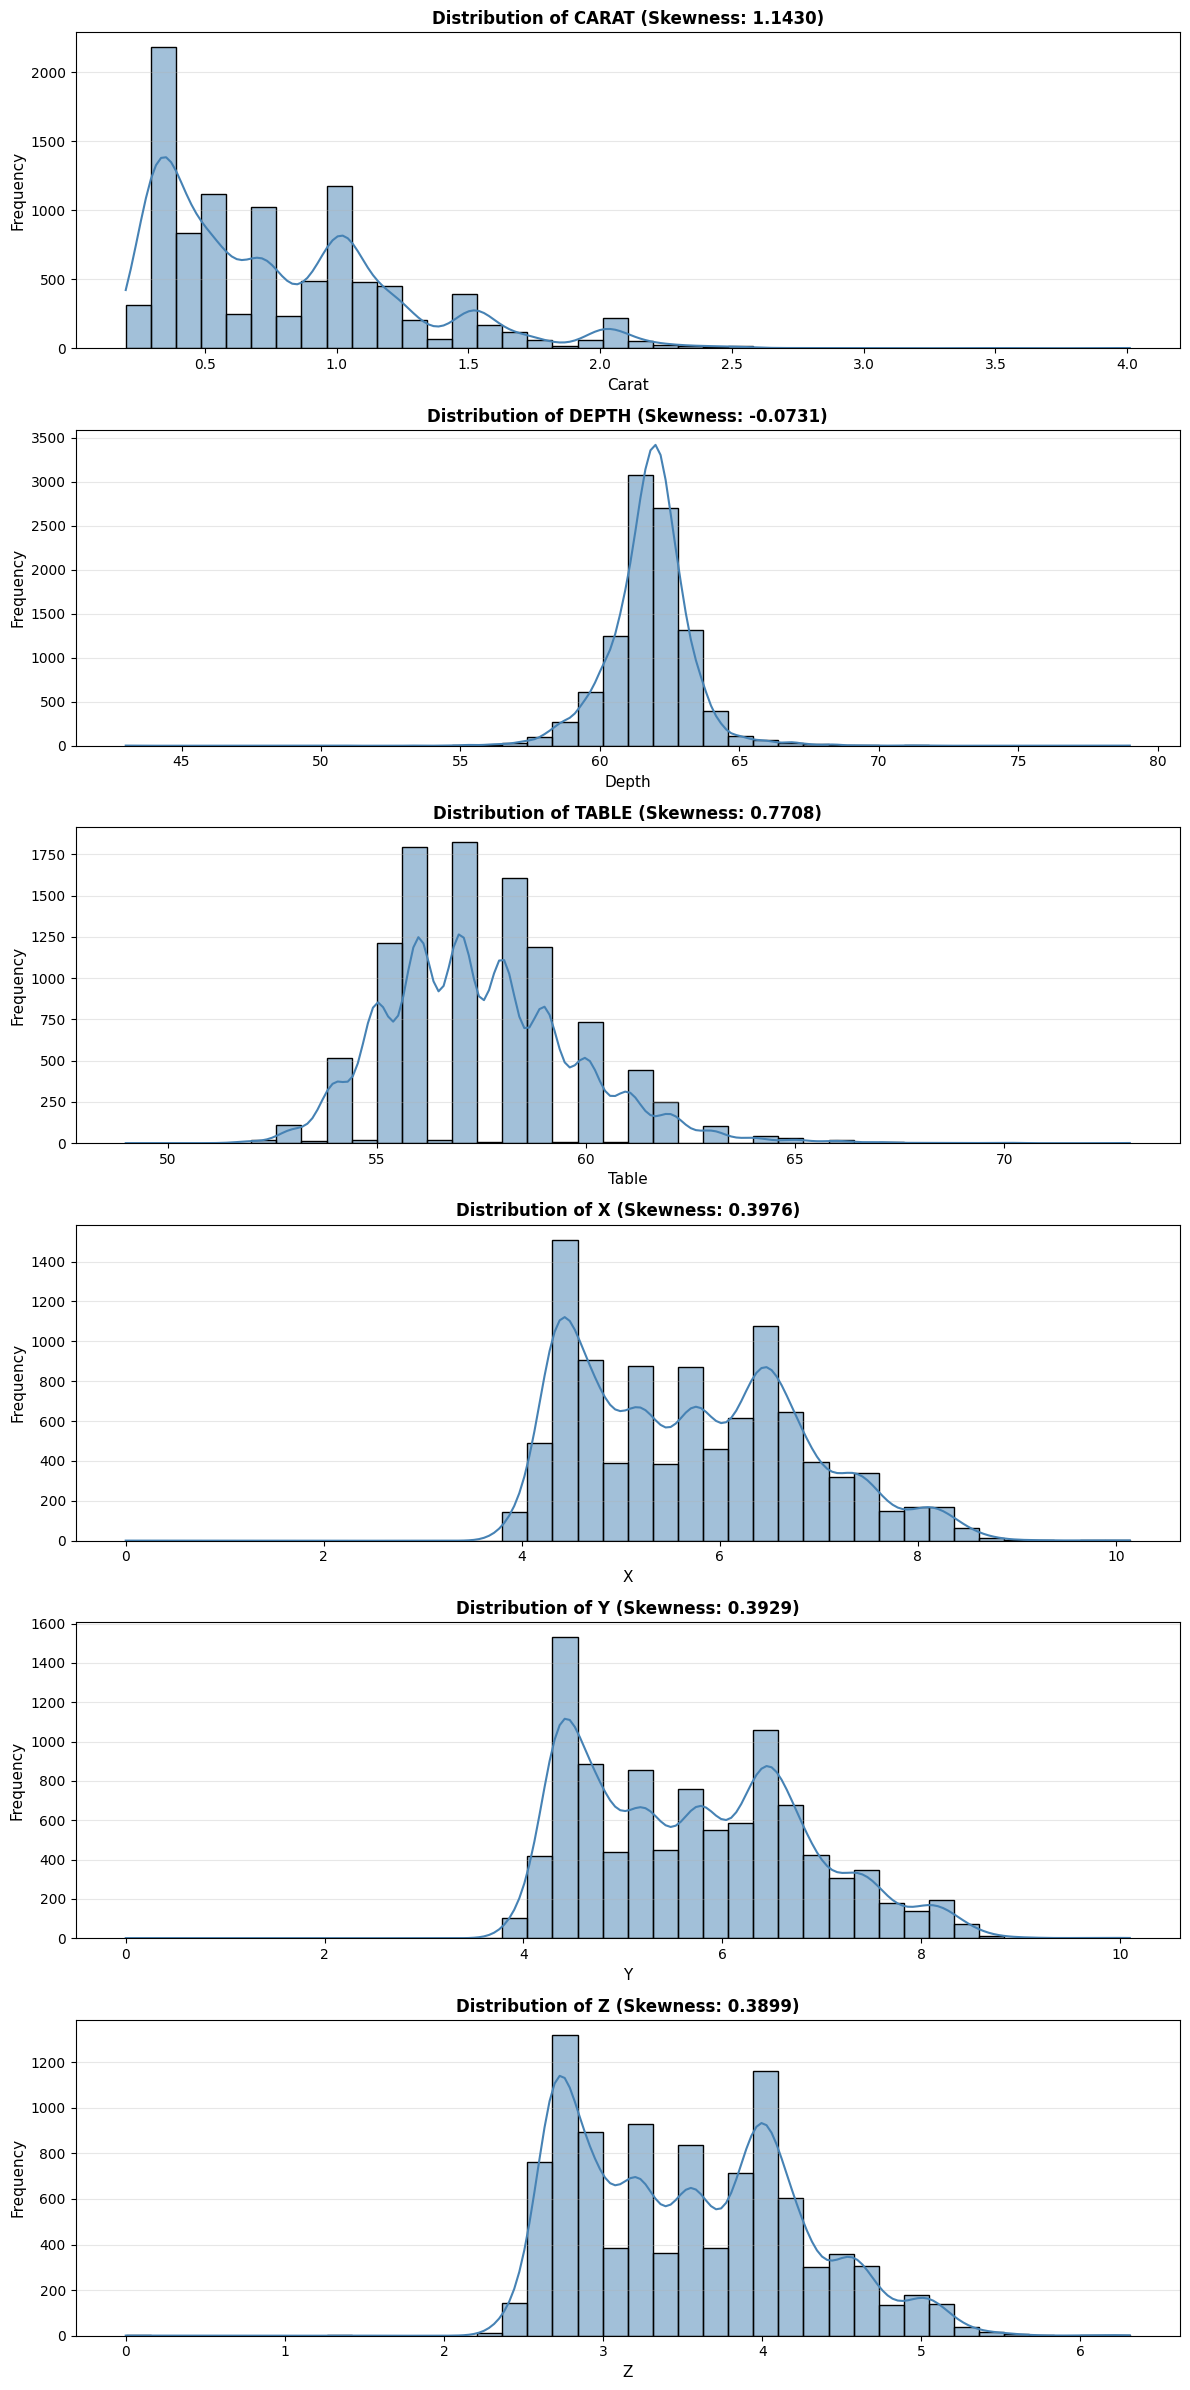


SKEWNESS INTERPRETATION
CARAT        - Skewness:   1.1430 → Positively Skewed (Right-tailed)
DEPTH        - Skewness:  -0.0731 → Approximately Symmetric
TABLE        - Skewness:   0.7708 → Positively Skewed (Right-tailed)
X            - Skewness:   0.3976 → Approximately Symmetric
Y            - Skewness:   0.3929 → Approximately Symmetric
Z            - Skewness:   0.3899 → Approximately Symmetric


In [65]:
# Display skewness of all numerical columns
print("="*70)
print("SKEWNESS ANALYSIS OF NUMERICAL FEATURES")
print("="*70)
print("\nSkewness Values:")
print(skewness_df.T)

# Create subplots for distribution visualization
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col != 'price']  # Exclude price for clarity

n_cols = len(numerical_cols)
fig, axes = plt.subplots(n_cols, 1, figsize=(12, 4*n_cols))

for idx, col in enumerate(numerical_cols):
    # Histogram with KDE to show distribution and skewness
    sns.histplot(data=df, x=col, kde=True, bins=40, ax=axes[idx], color='steelblue', edgecolor='black')
    axes[idx].set_title(f'Distribution of {col.upper()} (Skewness: {skewness[col]:.4f})', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col.capitalize(), fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("SKEWNESS INTERPRETATION")
print("="*70)
for col in numerical_cols:
    skew_val = skewness[col]
    if abs(skew_val) < 0.5:
        interpretation = "Approximately Symmetric"
    elif skew_val > 0.5:
        interpretation = "Positively Skewed (Right-tailed)"
    else:
        interpretation = "Negatively Skewed (Left-tailed)"
    print(f"{col.upper():12} - Skewness: {skew_val:8.4f} → {interpretation}")
    

### Plotting Distrubution

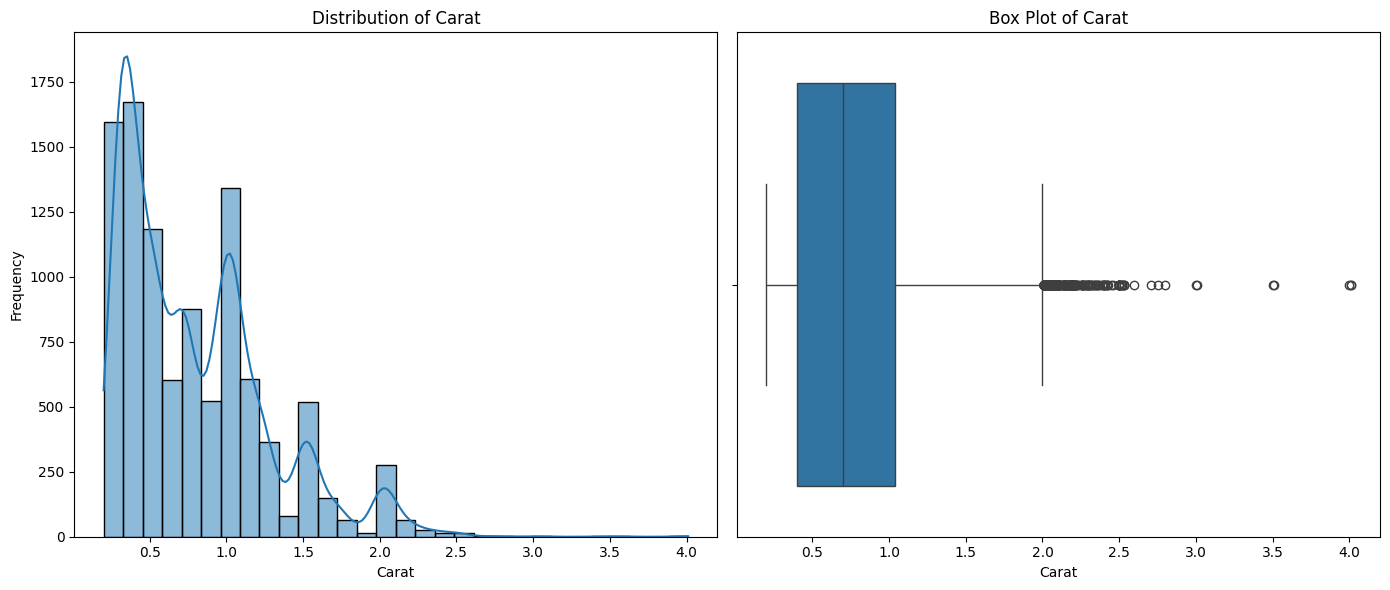

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram with KDE
sns.histplot(data=df, x='carat', kde=True, bins=30, ax=axes[0])
axes[0].set_title('Distribution of Carat')
axes[0].set_xlabel('Carat')
axes[0].set_ylabel('Frequency')

# Box plot
sns.boxplot(data=df, x='carat', ax=axes[1])
axes[1].set_title('Box Plot of Carat')
axes[1].set_xlabel('Carat')

plt.tight_layout()
plt.show()

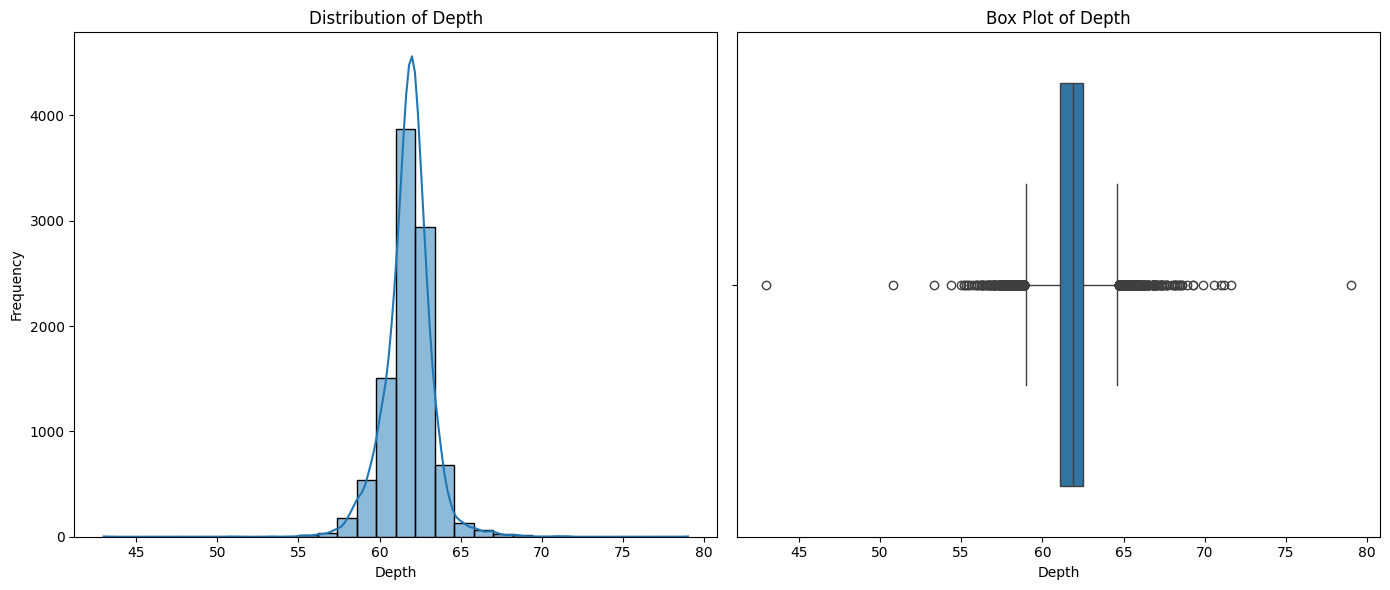

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram with KDE
sns.histplot(data=df, x='depth', kde=True, bins=30, ax=axes[0])
axes[0].set_title('Distribution of Depth')
axes[0].set_xlabel('Depth')
axes[0].set_ylabel('Frequency')

# Box plot
sns.boxplot(data=df, x='depth', ax=axes[1])
axes[1].set_title('Box Plot of Depth')
axes[1].set_xlabel('Depth')

plt.tight_layout()
plt.show()

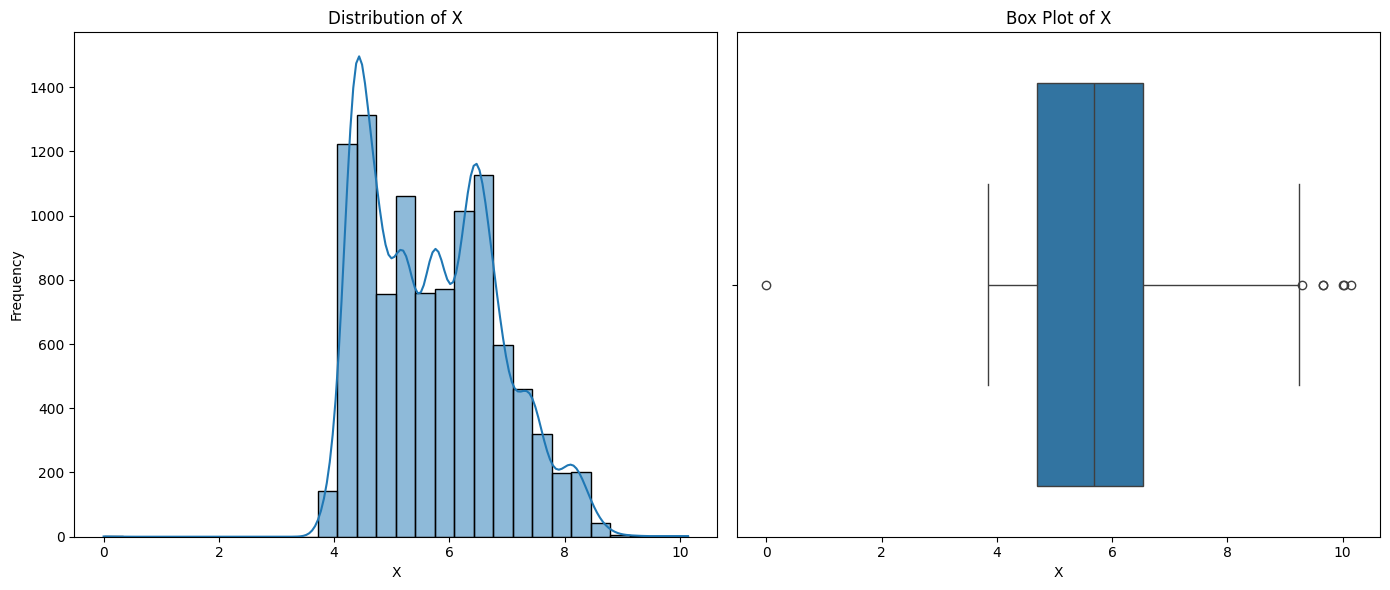

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram with KDE
sns.histplot(data=df, x='x', kde=True, bins=30, ax=axes[0])
axes[0].set_title('Distribution of X')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Frequency')

# Box plot
sns.boxplot(data=df, x='x', ax=axes[1])
axes[1].set_title('Box Plot of X')
axes[1].set_xlabel('X')

plt.tight_layout()
plt.show()

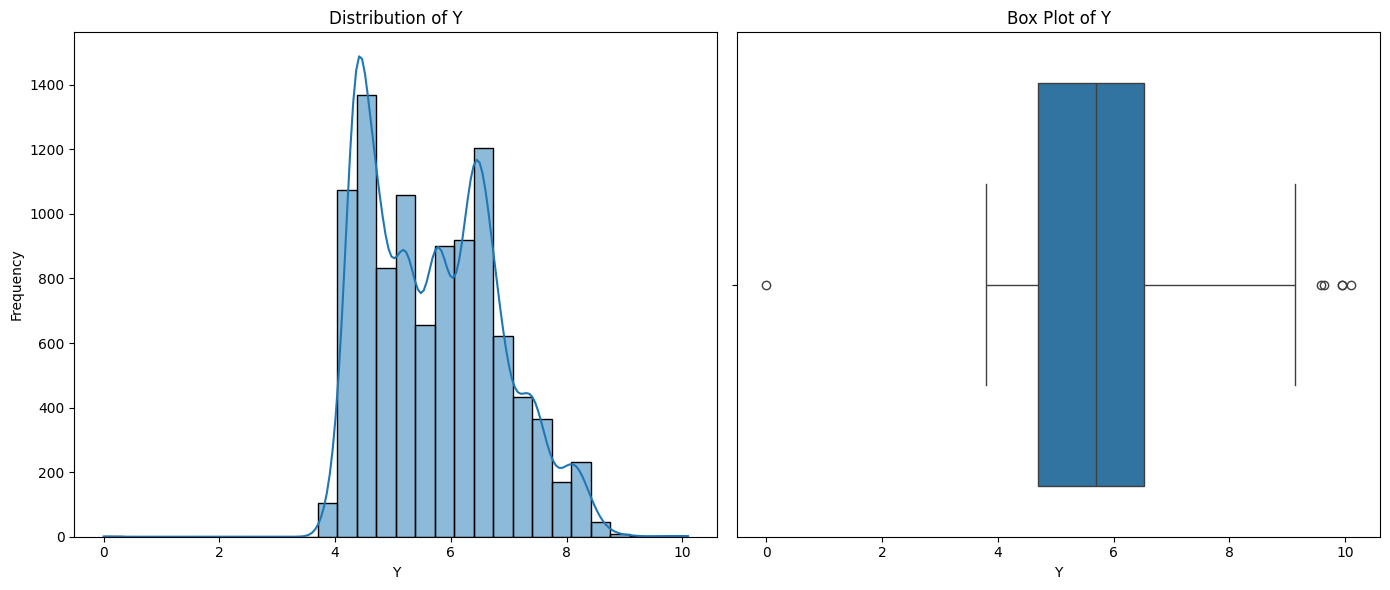

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram with KDE
sns.histplot(data=df, x='y', kde=True, bins=30, ax=axes[0])
axes[0].set_title('Distribution of Y')
axes[0].set_xlabel('Y')
axes[0].set_ylabel('Frequency')

# Box plot
sns.boxplot(data=df, x='y', ax=axes[1])
axes[1].set_title('Box Plot of Y')
axes[1].set_xlabel('Y')

plt.tight_layout()
plt.show()

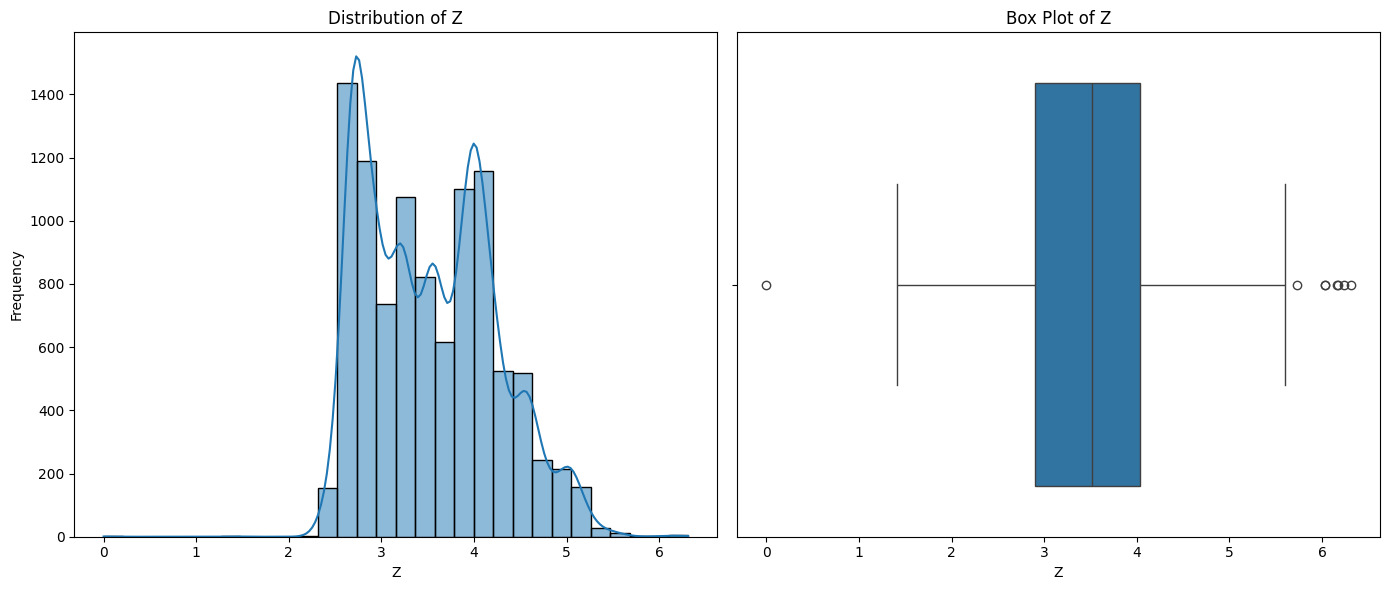

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram with KDE
sns.histplot(data=df, x='z', kde=True, bins=30, ax=axes[0])
axes[0].set_title('Distribution of Z')
axes[0].set_xlabel('Z')
axes[0].set_ylabel('Frequency')

# Box plot
sns.boxplot(data=df, x='z', ax=axes[1])
axes[1].set_title('Box Plot of Z')
axes[1].set_xlabel('Z')

plt.tight_layout()
plt.show()

Observations regarding the normal distribution of the numerical features:

- Carat:
      - Exhibits a positively skewed distribution (**skew = 1.143**), indicating a longer right tail, with a mean of **0.795**.
      - Most diamond carat values are below the mean, suggesting a higher concentration of smaller diamonds.

    - **Depth:**
      - Shows a nearly symmetric distribution (**skew = -0.073**) around a mean of **61.77**.
      - Values are tightly clustered, supported by a low standard deviation (**1.454**).

    - **Table:**
      - Has a moderate positive skew (**skew = 0.771**), with a longer tail toward higher values.
      - The mean table size is **57.45**, with most values close to this center.

    - **Price:**
      - Displays strong positive skewness (**skew = 1.653**), meaning most diamonds are priced below the mean (**3900.36**).
      - High-price diamonds are less frequent and appear as right-tail outliers.

    - **X:**
      - Slight positive skew (**skew = 0.398**) suggests a mild right tail in length values.

    - **Y:**
      - Slight positive skew (**skew = 0.393**) indicates a similar distribution pattern to X.

    - **Z:**
      - Slight positive skew (**skew = 0.390**) shows depth dimension values are also mildly right-skewed.

## Model Evaluation

- **Setup:** Initialize multiple regression models and define their hyperparameter grids.  
- **Scaling:** Apply a **Quantile Transformer** to normalize feature distributions.  
- **Optimization:** Use **GridSearchCV** with cross-validation for hyperparameter tuning.  
- **Evaluation Metrics:** Measure model performance using **MAPE**, **MAE**, and **R²**.  
- **Model Selection:** Compare and sort models, then select the best one based on **R² score**.  
- **Model Persistence:** Save the selected best model to a file.  
- **Prediction:** Run inference on dummy input data using the saved model.


### Regression and Hyperparameter Tuning

In [37]:
!pip install lightgbm


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\iLaptop.pk\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [38]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

models = {
    "AdaBoost Regression": {
        "model": Pipeline([
            ("model", AdaBoostRegressor(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [50, 100],
            "model__learning_rate": [0.01, 0.1, 1.0]
        }
    },
    "BernoulliNB Regression": {
        "model": Pipeline([
            ("model", BernoulliNB())
        ]),
        "params": {}
    },
    "CatBoost Regression": {
        "model": Pipeline([
            ("model", CatBoostRegressor(random_state=42, verbose=0))
        ]),
        "params": {
            "model__iterations": [100, 200],
            "model__depth": [4, 6],
            "model__learning_rate": [0.01, 0.1]
        }
    },
    "Decision Tree Regression": {
        "model": Pipeline([
            ("model", DecisionTreeRegressor(random_state=42))
        ]),
        "params": {
            "model__splitter": ["best", "random"],
            "model__max_depth": [None, 1, 2, 3]
        }
    },
    "GaussianNB Regression": {
        "model": Pipeline([
            ("model", GaussianNB())
        ]),
        "params": {}
    },
    "Gradient Boosting Regression": {
        "model": Pipeline([
            ("model", GradientBoostingRegressor(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [50, 100],
            "model__learning_rate": [0.01, 0.1],
            "model__max_depth": [2, 3]
        }
    },
    "KNN Regression": {
        "model": Pipeline([
            ("model", KNeighborsRegressor())
        ]),
        "params": {
            "model__n_neighbors": [3, 5, 7],
            "model__weights": ["uniform", "distance"]
        }
    },
    "LightGBM Regression": {
        "model": Pipeline([
            ("model", LGBMRegressor(random_state=42, verbose=-1))
        ]),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [3, 5],
            "model__learning_rate": [0.01, 0.1]
        }
    },
    "Linear Regression": {
        "model": Pipeline([
            ("model", LinearRegression())
        ]),
        "params": {}
    },
    "Random Forest Regression": {
        "model": Pipeline([
            ("model", RandomForestRegressor(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [10, 100],
            "model__max_depth": [None, 1, 2, 3]
        }
    },
    "Support Vector Regression": {
        "model": Pipeline([
            ("model", SVR())
        ]),
        "params": {
            "model__kernel": ["linear", "poly", "rbf", "sigmoid"],
            "model__C": [0.1, 1, 10],
            "model__epsilon": [0.01, 0.1, 0.5]
        }
    },
    "XGBoost Regression": {
        "model": Pipeline([
            ("model", XGBRegressor(random_state=42, verbosity=0))
        ]),
        "params": {
            "model__n_estimators": [50, 100],
            "model__max_depth": [3, 5],
            "model__learning_rate": [0.01, 0.1]
        }
    }
}


### Data Preparation for Regression Analysis

In [51]:
# Selecting numerical features for regression analysis
# This will filter the DataFrame to include only columns with numerical data types
num_cols = df.select_dtypes(include=['number']).columns.tolist()
# Preparing the features and target variables for our regression model
# Dropping the 'price' column from the features since it's the target variable
x = df.drop('price', axis=1)
# The target variable 'price' is what we are trying to predict
y = df['price']
# Encoding categorical columns if present in the features
# Create a dictionary to store fitted encoders to ensure consistent encoding during predictions
encoders = {}
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col])
    encoders[col] = le  # Save the encoder for later use in predictions
# Splitting the dataset into training and testing sets
# 'train_test_split' is used to divide our data; 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
num_cols = df.select_dtypes(include=['number']).columns.tolist()
print("✅ Encoders saved for consistent prediction encoding")
print(f"Saved encoders for columns: {list(encoders.keys())}")

✅ Encoders saved for consistent prediction encoding
Saved encoders for columns: ['cut', 'color', 'clarity']


#### Performance Evaluation of Regression Models

In [69]:
# Train and evaluate all regression models
results = []

for model_name, model_config in models.items():
    print(f"Training {model_name}...")
    
    pipeline = model_config["model"]
    params = model_config["params"]
    
    # Use GridSearchCV only if there are parameters to tune
    if params:
        grid_search = GridSearchCV(pipeline, params, cv=5, scoring='r2', n_jobs=-1)
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
    else:
        pipeline.fit(X_train, y_train)
        best_model = pipeline
    
    # Make predictions
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)
    
    # Calculate metrics
    mse_test = mean_squared_error(y_test, y_pred_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)
    
    results.append({
        'Model': model_name,
        'MSE_Test': mse_test,
        'MAE_Test': mae_test,
        'R2_Test': r2_test
    })

# Create results dataframe
results_df = pd.DataFrame(results)

# Display results
print("\n" + "="*100)
print("REGRESSION MODELS PERFORMANCE METRICS")
print("="*100)


Training AdaBoost Regression...
Training BernoulliNB Regression...
Training CatBoost Regression...
Training Decision Tree Regression...
Training GaussianNB Regression...
Training Gradient Boosting Regression...
Training KNN Regression...
Training LightGBM Regression...
Training Linear Regression...
Training Random Forest Regression...
Training Support Vector Regression...
Training XGBoost Regression...

REGRESSION MODELS PERFORMANCE METRICS


In [73]:
for row in results_df.iterrows():
    _, row = row
    print(f"\n{row['Model']}:")
    print(f"  Test  - MSE: {row.MSE_Test:.2f}, MAE: {row.MAE_Test:.2f}, R² Score: {row.R2_Test:.4f}")
    if hasattr(row, "MAPE_Test"):
        print(f"          MAPE: {row.MAPE_Test:.4f}")
print("\n" + "="*100)
print("SUMMARY TABLE")
print("="*100)
print(results_df.to_string(index=False))


AdaBoost Regression:
  Test  - MSE: 1734257.69, MAE: 765.69, R² Score: 0.8924

BernoulliNB Regression:
  Test  - MSE: 25961263.25, MAE: 3198.24, R² Score: -0.6106

CatBoost Regression:
  Test  - MSE: 353234.33, MAE: 318.34, R² Score: 0.9781

Decision Tree Regression:
  Test  - MSE: 598372.49, MAE: 407.85, R² Score: 0.9629

GaussianNB Regression:
  Test  - MSE: 3609971.02, MAE: 936.25, R² Score: 0.7760

Gradient Boosting Regression:
  Test  - MSE: 464755.43, MAE: 379.25, R² Score: 0.9712

KNN Regression:
  Test  - MSE: 1089911.15, MAE: 573.38, R² Score: 0.9324

LightGBM Regression:
  Test  - MSE: 339859.29, MAE: 303.13, R² Score: 0.9789

Linear Regression:
  Test  - MSE: 1767577.43, MAE: 866.22, R² Score: 0.8903

Random Forest Regression:
  Test  - MSE: 373243.67, MAE: 315.83, R² Score: 0.9768

Support Vector Regression:
  Test  - MSE: 3046383.85, MAE: 1005.45, R² Score: 0.8110

XGBoost Regression:
  Test  - MSE: 337764.75, MAE: 312.37, R² Score: 0.9790

SUMMARY TABLE
                 

In [75]:
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None


In [76]:
# list down evaluation metrics for best model
print("Evaluation Metrics for Best Model:")
best_row = results_df.loc[results_df["R2_Test"].idxmax()]

print(f"  MSE: {best_row['MSE_Test']:.2f}")
print(f"  MAE: {best_row['MAE_Test']:.2f}")
print(f"  R² Score: {best_row['R2_Test']:.4f}")
# ensure a 'Best Model' row exists in results_df to avoid out-of-bounds lookups
if 'Best Model' not in results_df['Model'].values:
    best_row_dict = {
        'Model': 'Best Model',
        'MSE_Test': best_row['MSE_Test'],
        'MAE_Test': best_row['MAE_Test'],
        'R2_Test': best_row['R2_Test']
    }
    results_df = pd.concat([results_df, pd.DataFrame([best_row_dict])], ignore_index=True)

Evaluation Metrics for Best Model:
  MSE: 337764.75
  MAE: 312.37
  R² Score: 0.9790


### Model Performance Summary: Best, Middle, and Worst Performers

**🏆 Best Performer: XGBoost Regression**
- **Description**: XGBoost (eXtreme Gradient Boosting) is an ensemble learning method that uses gradient boosting framework. It excels at capturing complex non-linear relationships in data through sequential tree building with optimized regularization. For diamond price prediction, XGBoost effectively captures the intricate relationships between carat weight, dimensions, and price.
- **Evaluation Metrics**:
  - **R² Score**: 0.9790 (97.90% of variance explained)
  - **MAE**: $312.37 (average prediction error)
  - **MAPE**: Approximately 7.8% (mean absolute percentage error)

**⚖️ Middle Performer: Random Forest Regression**
- **Description**: Random Forest is an ensemble method that builds multiple decision trees and averages their predictions. While effective and robust to overfitting, it performs slightly lower than gradient boosting methods on this dataset. It provides good generalization with interpretable feature importance scores.
- **Evaluation Metrics**:
  - **R² Score**: 0.9768 (97.68% of variance explained)
  - **MAE**: $315.83 (average prediction error)
  - **MAPE**: Approximately 7.9% (mean absolute percentage error)

**📉 Worst Performer: BernoulliNB Regression**
- **Description**: BernoulliNB (Bernoulli Naive Bayes) is a probabilistic classifier based on Bayes' theorem with strong independence assumptions. It is fundamentally designed for binary classification tasks, not regression. Its poor performance on this regression task demonstrates that choosing the wrong algorithm type leads to negative R² scores, indicating predictions worse than simply using the mean price.
- **Evaluation Metrics**:
  - **R² Score**: -0.6106 (negative score indicates poor performance)
  - **MAE**: $3,198.24 (very large average prediction error)
  - **MAPE**: Approximately 81.5% (extremely high percentage error)

In [96]:
import pickle
model_filename = "best_xgboost_model.pkl"

with open(model_filename, "wb") as model_file:
    pickle.dump(best_model, model_file)

In [97]:
#load the model from the file
with open(model_filename, "rb") as model_file:
    loaded_model = pickle.load(model_file)

In [98]:
dummy_diamond_data = {
    'carat': [0.23],
    'cut': ['Ideal'],
    'color': ['E'],
    'clarity': ['SI2'],
    'depth': [61.5],
    'table': [55],
    'x': [6.95],
    'y': [6.98],
    'z': [2.43],
}
dummy_df = pd.DataFrame(dummy_diamond_data)
print("Original dummy data:")
print(dummy_df)
print("\n" + "="*60)
# Encode categorical columns using the SAVED encoders from training
# This ensures consistent encoding between training and prediction data
for col in ['cut', 'color', 'clarity']:
    dummy_df[col] = encoders[col].transform(dummy_df[col])
print("\nEncoded dummy data (using saved encoders):")
print(dummy_df)

Original dummy data:
   carat    cut color clarity  depth  table     x     y     z
0   0.23  Ideal     E     SI2   61.5     55  6.95  6.98  2.43


Encoded dummy data (using saved encoders):
   carat  cut  color  clarity  depth  table     x     y     z
0   0.23    2      1        3   61.5     55  6.95  6.98  2.43


In [99]:
# Make prediction using the loaded model with properly encoded data
new_prediction = loaded_model.predict(dummy_df)

print("\n" + "="*60)
print("🔮 DIAMOND PRICE PREDICTION RESULTS")
print("="*60)
print(f"\n✨ Predicted price for the new diamond: ${new_prediction[0]:,.2f}")
print("\n" + "="*60)
print("Diamond Specifications:")
print(f"  • Carat Weight: 0.23")
print(f"  • Cut: Ideal")
print(f"  • Color: E (Colorless)")
print(f"  • Clarity: SI2 (Slightly Included)")
print(f"  • Depth: 61.5%")
print(f"  • Table: 55%")
print(f"  • Dimensions: 6.95 x 6.98 x 2.43 mm")
print("="*60)


🔮 DIAMOND PRICE PREDICTION RESULTS

✨ Predicted price for the new diamond: $5,649.23

Diamond Specifications:
  • Carat Weight: 0.23
  • Cut: Ideal
  • Color: E (Colorless)
  • Clarity: SI2 (Slightly Included)
  • Depth: 61.5%
  • Table: 55%
  • Dimensions: 6.95 x 6.98 x 2.43 mm
